# Mini Project 5-3 Explore Sampling

## Introduction
In this project, you will engage in effective sampling of a dataset in order to make it easier to analyze. As a data professional you will often work with extremely large datasets, and utilizing proper sampling techniques helps you improve your efficiency in this work. 

For this project, you are a member of an analytics team for the Environmental Protection Agency. You are assigned to analyze data on air quality with respect to carbon monoxide—a major air pollutant—and report your findings. The data utilized in this project includes information from over 200 sites, identified by their state name, county name, city name, and local site name. You will use effective sampling within this dataset. 

## Step 1: Imports

### Import packages

Import `pandas`,  `numpy`, `matplotlib`, `statsmodels`, and `scipy`. 

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
import scipy


### Load the dataset

As shown in this cell, the dataset has been automatically loaded in for you. You do not need to download the .csv file, or provide more code, in order to access the dataset and proceed with this lab. Please continue with this activity by completing the following instructions.

In [4]:
# Import data.
df = pd.read_csv("C:/Users/prani/Downloads/modified_c4_epa_air_quality.csv")

## Step 2: Data exploration

### Examine the data

To understand how the dataset is structured, examine the first 10 rows of the data.

In [5]:
# First 10 rows of the data
df.head(10)

,date_local,state_name,county_name,city_name,local_site_name,parameter_name,units_of_measure,aqi_log
0,2018-01-01,Arizona,Maricopa,Buckeye,BUCKEYE,Carbon monoxide,Parts per million,2.079442
1,2018-01-01,Ohio,Belmont,Shadyside,Shadyside,Carbon monoxide,Parts per million,1.791759
2,2018-01-01,Wyoming,Teton,Not in a city,Yellowstone National Park - Old Faithful Snow ...,Carbon monoxide,Parts per million,1.098612
3,2018-01-01,Pennsylvania,Philadelphia,Philadelphia,North East Waste (NEW),Carbon monoxide,Parts per million,1.386294
4,2018-01-01,Iowa,Polk,Des Moines,CARPENTER,Carbon monoxide,Parts per million,1.386294
5,2018-01-01,Hawaii,Honolulu,Not in a city,Kapolei,Carbon monoxide,Parts per million,2.708050
6,2018-01-01,Hawaii,Honolulu,Not in a city,Kapolei,Carbon monoxide,Parts per million,1.098612
7,2018-01-01,Pennsylvania,Erie,Erie,NaN,Carbon monoxide,Parts per million,1.098612
8,2018-01-01,Hawaii,Honolulu,Honolulu,Honolulu,Carbon monoxide,Parts per million,1.791759
9,2018-01-01,Colorado,Larimer,Fort Collins,Fort Collins - CSU - S. Mason,Carbon monoxide,Parts per million,1.945910


### Generate a table of descriptive statistics

Generate a table of some descriptive statistics about the data. Specify that all columns of the input be included in the output.

In [7]:
df.describe(include='all')

,date_local,state_name,county_name,city_name,local_site_name,parameter_name,units_of_measure,aqi_log
count,260,260,260,260,257,260,260,260.000000
unique,1,52,149,190,253,1,1,NaN
top,2018-01-01,California,Los Angeles,Not in a city,Kapolei,Carbon monoxide,Parts per million,NaN
freq,260,66,14,21,2,260,260,NaN
mean,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.766921
std,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.714716
min,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000
25%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.098612
50%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.791759
75%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.302585


**Question:** Based on the preceding table of descriptive statistics, what is the mean value of the `aqi` column? 

A: The mean value of the aqi_log column is 1.766921.

**Question:** Based on the preceding table of descriptive statistics, what do you notice about the count value for the `aqi` column?

A: The count for the aqi_log column is 260, which means there are no missing values in this column — every row has an AQI reading.

### Use the `mean()` function on the `aqi`  column

Now, use the `mean()` function on the `aqi`  column and assign the value to a variable `population_mean`. The value should be the same as the one generated by the `describe()` method in the above table. 

In [8]:
population_mean = df['aqi_log'].mean()
print(f"Population Mean: {population_mean}")


Population Mean: 1.7669210929985582


## Step 3: Statistical tests

### Sample with replacement

First, name a new variable `sampled_data`. Then, use the `sample()` dataframe method to draw 50 samples from `epa_data`. Set `replace` equal to `'True'` to specify sampling with replacement. For `random_state`, choose an arbitrary number for random seed. Make that arbitrary number `42`.

In [11]:
sampled_data = df.sample(n=50, replace=True, random_state=42)



### Output the first 10 rows

Output the first 10 rows of the DataFrame. 

In [10]:
sampled_data.head(10)

,date_local,state_name,county_name,city_name,local_site_name,parameter_name,units_of_measure,aqi_log
102,2018-01-01,Texas,Harris,Houston,Clinton,Carbon monoxide,Parts per million,1.098612
106,2018-01-01,California,Imperial,Calexico,Calexico-Ethel Street,Carbon monoxide,Parts per million,3.295837
71,2018-01-01,Alabama,Jefferson,Birmingham,Arkadelphia/Near Road,Carbon monoxide,Parts per million,1.098612
188,2018-01-01,Arizona,Maricopa,Tempe,Diablo,Carbon monoxide,Parts per million,2.397895
20,2018-01-01,Virginia,Roanoke,Vinton,East Vinton Elementary School,Carbon monoxide,Parts per million,0.693147
102,2018-01-01,Texas,Harris,Houston,Clinton,Carbon monoxide,Parts per million,1.098612
121,2018-01-01,North Carolina,Mecklenburg,Charlotte,Garinger High School,Carbon monoxide,Parts per million,1.098612
214,2018-01-01,Florida,Broward,Davie,Daniela Banu NCORE,Carbon monoxide,Parts per million,1.791759
87,2018-01-01,California,Humboldt,Eureka,Jacobs,Carbon monoxide,Parts per million,1.791759
99,2018-01-01,California,Santa Barbara,Goleta,Goleta,Carbon monoxide,Parts per million,1.386294


**Question:** In the DataFrame output, why is the row index 102 repeated twice? 

A: The sampling was done with replacement, meaning the same row can be selected more than once. That’s why row index 102 appears twice in the sampled data.

**Question:** What does `random_state` do?

A: The random_state parameter sets a seed for reproducibility. It ensures that you get the same random sample every time you run the code. Different seeds give different samples.

### Compute the mean value from the `aqi` column

Compute the mean value from the `aqi` column in `sampled_data` and assign the value to the variable `sample_mean`.

In [12]:
sample_mean = sampled_data['aqi_log'].mean()
print(f"Sample Mean: {sample_mean}")


Sample Mean: 1.6379981384419398


You have a 95% confidence interval for the mean district literacy rate that stretches from about X % to Y%. 

95% CI: (X, Y)

 **Question:**  Why is `sample_mean` different from `population_mean`?


A: The sample_mean is different from the population_mean because it is based on a random subset of the data. Sampling introduces random variation, especially with small sample sizes. This is expected — but if you took many samples, their means would cluster around the true population mean (Central Limit Theorem).

### Apply the central limit theorem

Imagine repeating the the earlier sample with replacement 10,000 times and obtaining 10,000 point estimates of the mean. In other words, imagine taking 10,000 random samples of 50 AQI values and computing the mean for each sample. According to the **central limit theorem**, the mean of a sampling distribution should be roughly equal to the population mean. Complete the following steps to compute the mean of the sampling distribution with 10,000 samples. 

* Create an empty list and assign it to a variable called `estimate_list`. 
* Iterate through a `for` loop 10,000 times. To do this, make sure to utilize the `range()` function to generate a sequence of numbers from 0 to 9,999. 
* In each iteration of the loop, use the `sample()` function to take a random sample (with replacement) of 50 AQI values from the population. Do not set `random_state` to a value.
* Use the list `append()` function to add the value of the sample `mean` to each item in the list.


In [13]:
estimate_list = []

for i in range(10000):
    sample = df['aqi_log'].sample(n=50, replace=True)
    estimate_list.append(sample.mean())


### Create a new DataFrame

Next, create a new DataFrame from the list of 10,000 estimates. Name the new variable `estimate_df`.

In [14]:
estimate_df = pd.DataFrame(estimate_list, columns=['sample_mean'])


### Compute the mean() of the sampling distribution

Next, compute the `mean()` of the sampling distribution of 10,000 random samples and store the result in a new variable `mean_sample_means`.

In [15]:
mean_sample_means = estimate_df['sample_mean'].mean()
print(f"Mean of sampling distribution: {mean_sample_means}")


Mean of sampling distribution: 1.7655859548736021


**Question:** What is the mean for the sampling distribution of 10,000 random samples?

In [16]:
# Q1: What is the mean for the sampling distribution of 10,000 random samples?
mean_sample_means = estimate_df['sample_mean'].mean()
print(f"The mean of the sampling distribution is: {mean_sample_means}")


The mean of the sampling distribution is: 1.7655859548736021


**Question:** How are the central limit theorem and random sampling (with replacement) related?

A: The Central Limit Theorem states that if you repeatedly draw random samples from a population and calculate their means, the distribution of those means will approximate a normal distribution, regardless of the shape of the original data. Sampling with replacement simulates this process by mimicking independent random sampling.

### Output the distribution using a histogram

Output the distribution of these estimates using a histogram. This provides an idea of the sampling distribution.

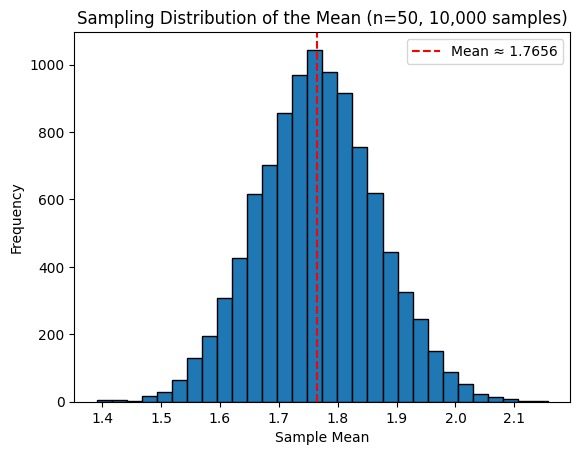

In [19]:

plt.hist(estimate_df['sample_mean'], bins=30, edgecolor='black')
plt.title('Sampling Distribution of the Mean (n=50, 10,000 samples)')
plt.xlabel('Sample Mean')
plt.ylabel('Frequency')
plt.axvline(mean_sample_means, color='red', linestyle='dashed', label=f"Mean ≈ {mean_sample_means:.4f}")
plt.legend()
plt.show()

### Calculate the standard error

Calculate the standard error of the mean AQI using the initial sample of 50. The **standard error** of a statistic measures the sample-to-sample variability of the sample statistic. It provides a numerical measure of sampling variability and answers the question: How far is a statistic based on one particular sample from the actual value of the statistic?

In [20]:
# Standard error = sample std dev / sqrt(sample size)
standard_error = sampled_data['aqi_log'].std(ddof=1) / np.sqrt(50)
print(f"Standard Error of the sample mean: {standard_error}")


Standard Error of the sample mean: 0.0945235150131964


## Step 4: Results and evaluation

###  Visualize the relationship between the sampling and normal distributions

Visualize the relationship between your sampling distribution of 10,000 estimates and the normal distribution.

1. Plot a histogram of the 10,000 sample means 
2. Add a vertical line indicating the mean of the first single sample of 50
3. Add another vertical line indicating the mean of the means of the 10,000 samples 
4. Add a third vertical line indicating the mean of the actual population

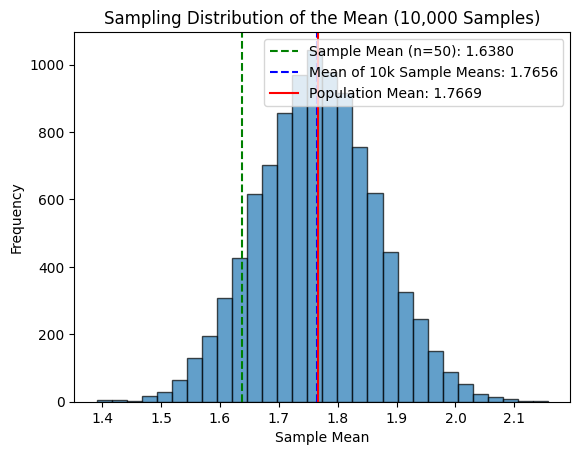

In [21]:
plt.hist(estimate_df['sample_mean'], bins=30, edgecolor='black', alpha=0.7)
plt.title('Sampling Distribution of the Mean (10,000 Samples)')
plt.xlabel('Sample Mean')
plt.ylabel('Frequency')

# 1. Vertical line for sample mean
plt.axvline(sample_mean, color='green', linestyle='dashed', label=f"Sample Mean (n=50): {sample_mean:.4f}")

# 2. Vertical line for mean of sample means
plt.axvline(mean_sample_means, color='blue', linestyle='dashed', label=f"Mean of 10k Sample Means: {mean_sample_means:.4f}")

# 3. Vertical line for population mean
plt.axvline(population_mean, color='red', linestyle='solid', label=f"Population Mean: {population_mean:.4f}")

plt.legend()
plt.show()


**Question:** What insights did you gain from the preceding sampling distribution?

A: The sampling distribution closely followed a normal curve, reinforcing the central limit theorem. It showed that even though individual sample means may vary, the average of many sample means is very close to the population mean. This demonstrates how reliable sampling can be when estimating population parameters.

# Considerations

**What are some key takeaways that you learned from this project?**

A: I learned how to perform statistical sampling with and without replacement, how to calculate sampling variability, and how to use the central limit theorem in practice. I also saw how standard error gives a precise estimate of how much a sample mean may vary from the true population mean.

**What findings would you share with others?**

A: I would share that with just 50 random samples, we were able to closely estimate the population mean. Repeating the process 10,000 times confirmed that the distribution of sample means is stable and predictable, reinforcing that sampling is a powerful and valid method of statistical inference.

**What would you convey to external readers?**

A: Sampling allows analysts to draw meaningful conclusions from large datasets without needing to evaluate every data point. Through random sampling and the central limit theorem, we can trust that well-drawn samples provide accurate insights — especially when supported by visual tools and error calculations.

